Multiple Linear Regression (MLR)

Importing the  Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error, r2_score

Loading the Dataset 

In [20]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

In [21]:
#displays 5 rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [22]:
#info & structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [23]:
#Statistical Summary
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [24]:
#missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [29]:
print(df.columns)

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')


Exploratory Data Analysis (EDA)

Price Distribution using histogram

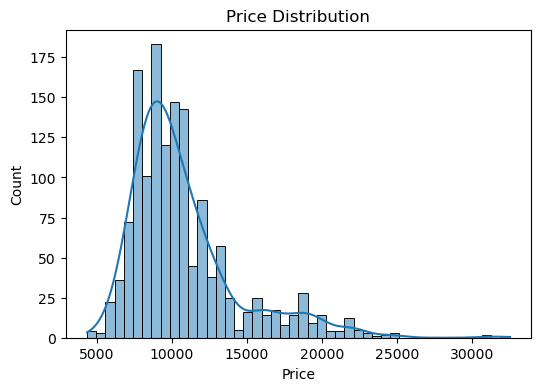

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

Correlation using Heatmap

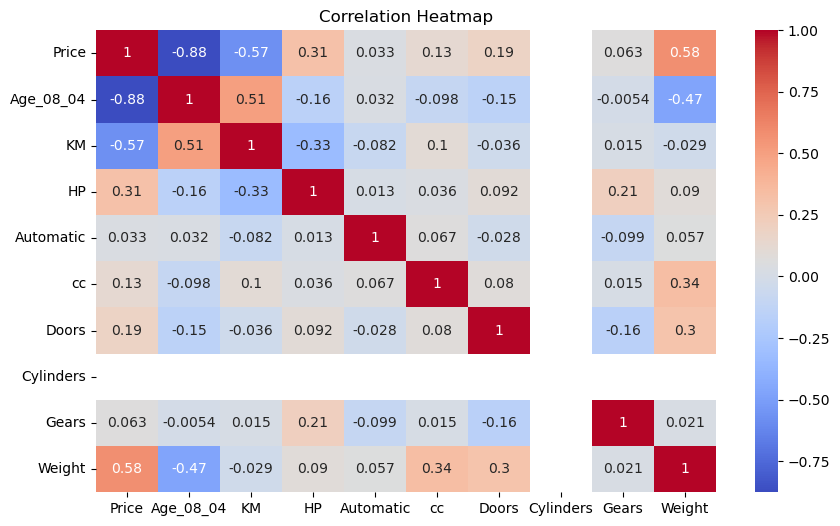

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

KM vs Price

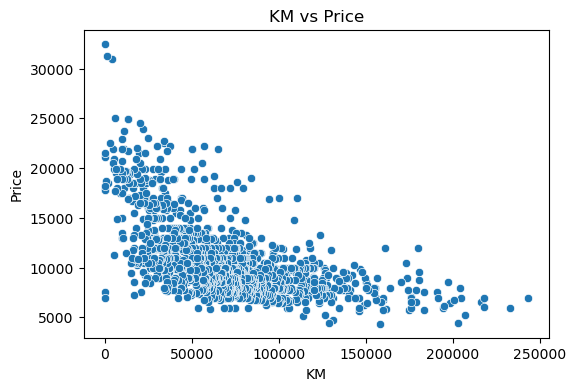

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='KM', y='Price', data=df)
plt.title("KM vs Price")
plt.show()

Age vs Price

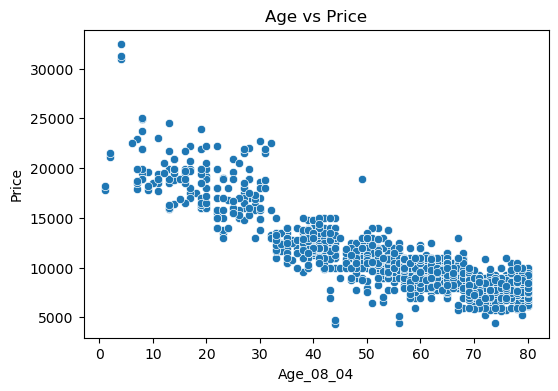

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.title("Age vs Price")
plt.show()

Data Preprocessing

In [33]:
#Converting Fuel_Type into numerical values
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

In [34]:
#Select Features and Target
X = df[['Age_08_04', 'KM', 'Fuel_Type','HP', 'Automatic', 'cc', 'Doors',
        'Cylinders','Gears','Weight']]
y = df['Price']

Splitting the  Dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

Building Multiple Linear Regression Models

In [36]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

Prediction

In [39]:
y_pred1 = model1.predict(X_test)

In [40]:
#Model Evaluation techniques
mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)
print("Mean Squared Error :", mse)
print("R2 Score :", r2)

Mean Squared Error : 2096851.1400177148
R2 Score : 0.8428476112017994


In [41]:
#Coefficients
coefficients = pd.DataFrame({ 'Feature': X.columns,'Coefficient': model1.coef_})
print(coefficients)

     Feature   Coefficient
0  Age_08_04 -1.214362e+02
1         KM -1.693560e-02
2  Fuel_Type  8.620564e+02
3         HP  2.065828e+01
4  Automatic  2.451969e+02
5         cc -7.351539e-02
6      Doors -3.627965e+01
7  Cylinders  1.023182e-12
8      Gears  5.302820e+02
9     Weight  2.351064e+01


#Building Model 2

In [42]:
X2 = df[['Age_08_04','KM', 'HP','Weight']]

y2 = df['Price']

In [43]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,y2, test_size=0.2, random_state=42)

In [44]:
model2 = LinearRegression() 

model2.fit(X_train2, y_train2)

LinearRegression()

In [45]:
y_pred2 = model2.predict(X_test2)

In [47]:
print("Model 2 R2 Score :", r2_score(y_test2, y_pred2))

Model 2 R2 Score : 0.8506068681500581


##Build Model 3

In [48]:
X3 = df[['Age_08_04','KM', 'Fuel_Type', 'Weight']]

y3 = df['Price']

In [49]:
X_train3, X_test3, y_train3, y_test3 = train_test_split( X3, y3, test_size=0.2, random_state=42)

In [53]:
model3 = LinearRegression()

model3.fit(X_train3, y_train3)

LinearRegression()

In [54]:
y_pred3 = model3.predict(X_test3)

In [55]:
print("Model 3 R2 Score :", r2_score(y_test3, y_pred3))

Model 3 R2 Score : 0.8274270252571694


###Ridge Regression

In [56]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("Ridge R2 Score :",
      r2_score(y_test, ridge_pred))

Ridge R2 Score : 0.8429634282301911


###Lasso Regression

In [57]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
print("Lasso R2 Score :",
      r2_score(y_test, lasso_pred))

Lasso R2 Score : 0.8429414838867533


###Final Comparison

In [58]:
print("Model 1 R2 Score :", r2)
print("Model 2 R2 Score :", r2_score(y_test2, y_pred2))
print("Model 3 R2 Score :", r2_score(y_test3, y_pred3))
print("Ridge R2 Score :", r2_score(y_test, ridge_pred))
print("Lasso R2 Score :", r2_score(y_test, lasso_pred))

Model 1 R2 Score : 0.8428476112017994
Model 2 R2 Score : 0.8506068681500581
Model 3 R2 Score : 0.8274270252571694
Ridge R2 Score : 0.8429634282301911
Lasso R2 Score : 0.8429414838867533


###CONCLUSION:
Multiple Linear Regression was used
to predict Toyota Corolla prices.

Different models were created and
evaluated using R2 Score and MSE.

Ridge and Lasso Regression were
also applied to improve model performance.